<a href="https://colab.research.google.com/github/zakari90/-DataAnalysis/blob/main/Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from pathlib import Path

sale_Path = "/content/drive/MyDrive/hsoub ai/Sales"
folder_path = Path(sale_Path)

# Get all CSV files
csv_files = list(folder_path.glob("*.csv"))

# List to hold individual dataframes
all_dfs = []

for file in csv_files:
    # Read the CSV
    df = pd.read_csv(file)
    df["month"] = file.stem.split()[0].split("_")[1]
    df.to_csv(file, index=False)
    all_dfs.append(df)

# Concatenate all dataframes
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df.info()
# combined_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
 6   month             186850 non-null  object
dtypes: object(7)
memory usage: 10.0+ MB


In [14]:
combined_df.isnull().sum()

,0
Order ID,545
Product,545
Quantity Ordered,545
Price Each,545
Order Date,545
Purchase Address,545
month,0


In [15]:
combined_df.nunique()

,0
Order ID,178438
Product,20
Quantity Ordered,10
Price Each,24
Order Date,142396
Purchase Address,140788
month,12


In [16]:
combined_df.duplicated().sum()

np.int64(1140)

In [17]:
combined_df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'month'],
      dtype='object')

In [18]:
combined_df["Product"].unique()

array(['iPhone', 'AA Batteries (4-pack)', '27in 4K Gaming Monitor',
       'Lightning Charging Cable', 'Apple Airpods Headphones',
       'USB-C Charging Cable', 'Bose SoundSport Headphones',
       '27in FHD Monitor', 'Wired Headphones', 'Macbook Pro Laptop',
       'Flatscreen TV', '20in Monitor', 'LG Dryer',
       'AAA Batteries (4-pack)', 'ThinkPad Laptop',
       '34in Ultrawide Monitor', nan, 'Google Phone', 'Vareebadd Phone',
       'LG Washing Machine', 'Product'], dtype=object)

In [19]:
combined_df.columns = [col.lower() for col in combined_df.columns]
combined_df.rename(columns={
    "order id": "order_id",
    "product": "product",
    "quantity ordered": "quantity_ordered",
    "price each": "price_each",
    "order date": "order_date",
    "purchase address": "purchase_address"
}, inplace=True)

combined_df.columns

Index(['order_id', 'product', 'quantity_ordered', 'price_each', 'order_date',
       'purchase_address', 'month'],
      dtype='object')

In [20]:
(combined_df.isnull().sum().sum()/len(combined_df))*100

np.float64(1.75006689858175)

In [21]:
combined_df.dropna(inplace=True)
combined_df.isnull().sum()

,0
order_id,0
product,0
quantity_ordered,0
price_each,0
order_date,0
purchase_address,0
month,0


In [23]:
combined_df = combined_df.astype({"quantity_ordered": int, "price_each": float})
combined_df.info()

ValueError: invalid literal for int() with base 10: 'Quantity Ordered': Error while type casting for column 'quantity_ordered'

In [26]:
combined_df['price_each'].unique()

array(['700', '3.84', '389.99', '14.95', '150', '11.95', '99.99',
       '149.99', '11.99', '1700', '300', '109.99', '600.0', '2.99',
       '999.99', '379.99', '600', '400', 'Price Each', '400.0', '150.0',
       '700.0', '1700.0', '300.0'], dtype=object)

In [27]:
combined_df = combined_df[combined_df['quantity_ordered'] != 'Quantity Ordered']
combined_df = combined_df.astype({"quantity_ordered": int, "price_each": float})
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          185950 non-null  object 
 1   product           185950 non-null  object 
 2   quantity_ordered  185950 non-null  int64  
 3   price_each        185950 non-null  float64
 4   order_date        185950 non-null  object 
 5   purchase_address  185950 non-null  object 
 6   month             185950 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 11.3+ MB


In [28]:
combined_df["sales"] = combined_df["quantity_ordered"] * combined_df["price_each"]
combined_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales
0,150502,iPhone,1,700.00,02/18/19 01:35,"866 Spruce St, Portland, ME 04101",February,700.00
1,150503,AA Batteries (4-pack),1,3.84,02/13/19 07:24,"18 13th St, San Francisco, CA 94016",February,3.84
2,150504,27in 4K Gaming Monitor,1,389.99,02/18/19 09:46,"52 6th St, New York City, NY 10001",February,389.99
3,150505,Lightning Charging Cable,1,14.95,02/02/19 16:47,"129 Cherry St, Atlanta, GA 30301",February,14.95
4,150506,AA Batteries (4-pack),2,3.84,02/28/19 20:32,"548 Lincoln St, Seattle, WA 98101",February,7.68


In [29]:
month_sales = combined_df.groupby('month')['sales'].agg(sales_sum = 'sum').sort_values(by="sales_sum", ascending=False).reset_index()
month_sales

,month,sales_sum
0,December,4619297.12
1,October,3736884.05
2,April,3396059.11
3,November,3198909.23
4,May,3144584.80
5,March,2809063.30
6,July,2646899.69
7,June,2578293.30
8,August,2244412.31
9,February,2203481.24


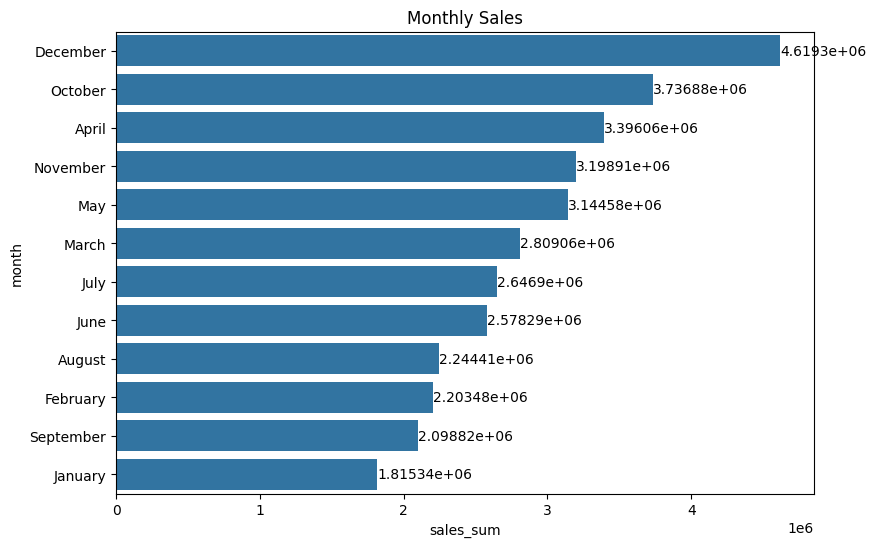

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='sales_sum', y='month', data=month_sales)
ax.set_title('Monthly Sales')
ax.bar_label(ax.containers[0])
plt.show()

In [31]:
combined_df["purchase_address"][0].split(",")[1].strip()
combined_df["city"] = combined_df["purchase_address"].apply(lambda x: x.split(",")[1].strip())
combined_df.head()

city_month_sales = combined_df.groupby('city')['sales'].agg(city_sales_sum = 'sum').sort_values(by="city_sales_sum", ascending=False).reset_index()
city_month_sales

,city,city_sales_sum
0,San Francisco,8262203.91
1,Los Angeles,5452570.80
2,New York City,4664317.43
3,Boston,3661642.01
4,Atlanta,2795498.58
5,Dallas,2767975.40
6,Seattle,2747755.48
7,Portland,2320490.61
8,Austin,1819581.75


/tmp/ipykernel_8975/2382466827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city_sales_sum', y='city', data=city_month_sales,palette='viridis')


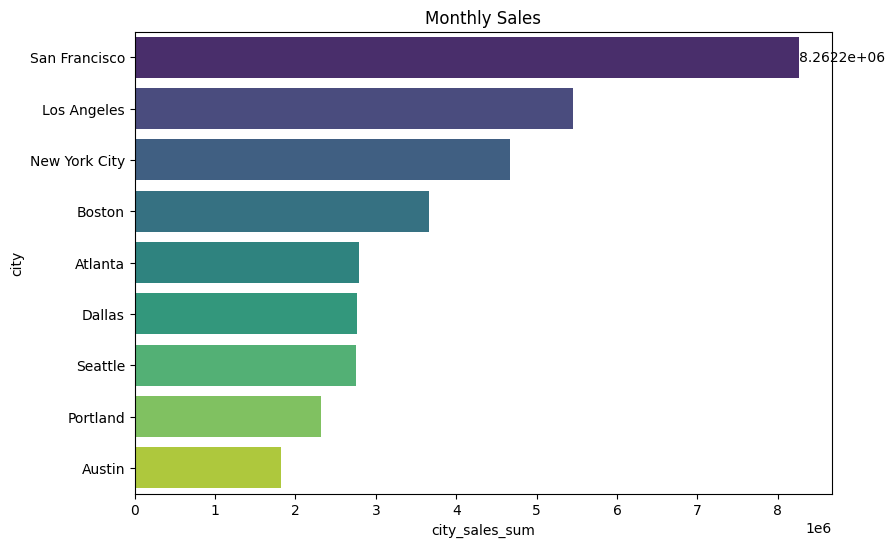

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x='city_sales_sum', y='city', data=city_month_sales,palette='viridis')
# ax.set_title('Monthly Sales')
plt.title('Monthly Sales')
ax.bar_label(ax.containers[0])
plt.show()

In [33]:
combined_df.nunique()

,0
order_id,178437
product,19
quantity_ordered,9
price_each,17
order_date,142395
purchase_address,140787
month,12
sales,54
city,9


In [34]:
combined_df["product"].unique()

array(['iPhone', 'AA Batteries (4-pack)', '27in 4K Gaming Monitor',
       'Lightning Charging Cable', 'Apple Airpods Headphones',
       'USB-C Charging Cable', 'Bose SoundSport Headphones',
       '27in FHD Monitor', 'Wired Headphones', 'Macbook Pro Laptop',
       'Flatscreen TV', '20in Monitor', 'LG Dryer',
       'AAA Batteries (4-pack)', 'ThinkPad Laptop',
       '34in Ultrawide Monitor', 'Google Phone', 'Vareebadd Phone',
       'LG Washing Machine'], dtype=object)

In [35]:
product_sales =combined_df.groupby('product')['quantity_ordered'].agg(quantity_ordered = 'sum').sort_values(by="quantity_ordered", ascending=False).reset_index()
product_sales

,product,quantity_ordered
0,AAA Batteries (4-pack),31017
1,AA Batteries (4-pack),27635
2,USB-C Charging Cable,23975
3,Lightning Charging Cable,23217
4,Wired Headphones,20557
5,Apple Airpods Headphones,15661
6,Bose SoundSport Headphones,13457
7,27in FHD Monitor,7550
8,iPhone,6849
9,27in 4K Gaming Monitor,6244


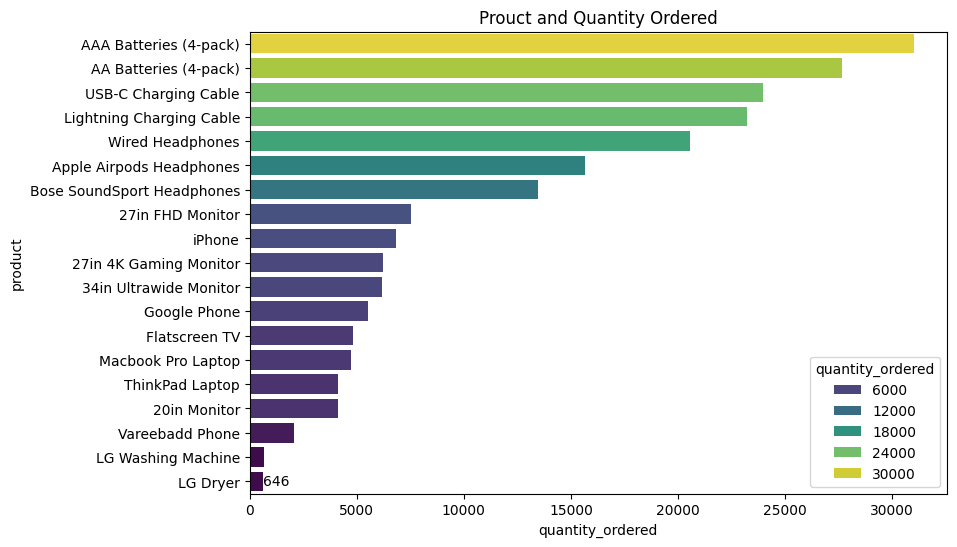

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.barplot(x = "quantity_ordered",
            y = "product",
            data = product_sales, hue="quantity_ordered",palette='viridis')

plt.title("Prouct and Quantity Ordered")

ax.bar_label(ax.containers[0])
plt.show()

In [37]:
combined_df["order_date"][0].split(" ")[1]

'01:35'

In [38]:
combined_df["time"] = combined_df["order_date"].apply(lambda x: x.split(" ")[1])
combined_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales,city,time
0,150502,iPhone,1,700.00,02/18/19 01:35,"866 Spruce St, Portland, ME 04101",February,700.00,Portland,01:35
1,150503,AA Batteries (4-pack),1,3.84,02/13/19 07:24,"18 13th St, San Francisco, CA 94016",February,3.84,San Francisco,07:24
2,150504,27in 4K Gaming Monitor,1,389.99,02/18/19 09:46,"52 6th St, New York City, NY 10001",February,389.99,New York City,09:46
3,150505,Lightning Charging Cable,1,14.95,02/02/19 16:47,"129 Cherry St, Atlanta, GA 30301",February,14.95,Atlanta,16:47
4,150506,AA Batteries (4-pack),2,3.84,02/28/19 20:32,"548 Lincoln St, Seattle, WA 98101",February,7.68,Seattle,20:32


In [39]:
sales_time = combined_df.groupby('time')['sales'].agg(sales_sum = 'sum').sort_values(by="sales_sum", ascending=False).reset_index()
sales_time.head()

,time,sales_sum
0,19:01,54503.14
1,12:21,54181.96
2,19:16,54156.39
3,20:13,53149.51
4,19:20,52903.41


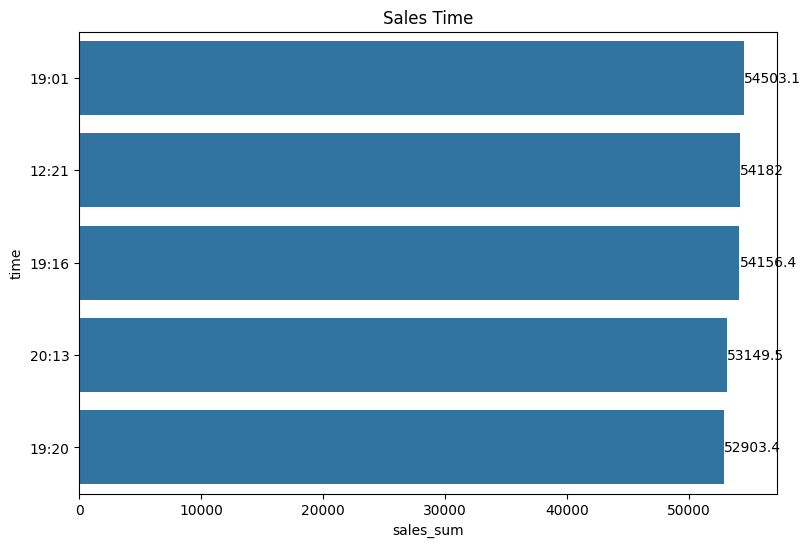

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))
ax = sns.barplot(x='sales_sum', y='time', data=sales_time.head())
ax.set_title('Sales Time')
ax.bar_label(ax.containers[0])
plt.show()

In [44]:
sales_time = combined_df.groupby('time')['product']
sales_time.head()

,product
0,iPhone
1,AA Batteries (4-pack)
2,27in 4K Gaming Monitor
3,Lightning Charging Cable
4,AA Batteries (4-pack)
...,...
145031,Wired Headphones
151961,Bose SoundSport Headphones
152822,Bose SoundSport Headphones
157203,Wired Headphones


In [54]:
product_by_time = combined_df.groupby('time')['product'].agg(product_count = 'count').sort_values(by="product_count", ascending=False).reset_index()
product_by_time.head()

,time,product_count
0,11:58,252
1,19:20,246
2,19:15,243
3,20:13,242
4,13:25,240


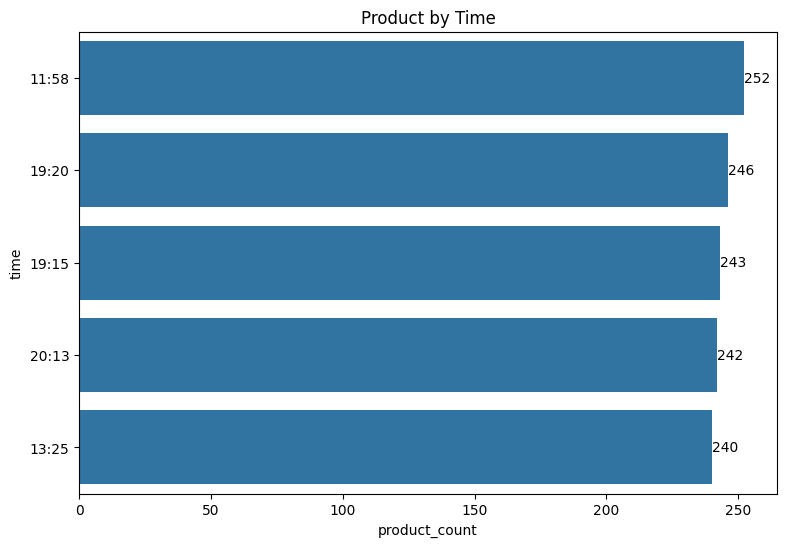

In [56]:
fig , ax = plt.subplots(figsize=(9, 6))
ax = sns.barplot(x='product_count', y='time', data=product_by_time.head())
ax.set_title('Product by Time')
ax.bar_label(ax.containers[0])
plt.show()